<a href="https://colab.research.google.com/github/Saibhossain/Agentic-framework/blob/main/BMI_calculator_workflow_in_Langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [2]:
!pip install langchain

In [3]:
!pip install langgraph

In [4]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.2 MB/s eta 0:00:00


# code

In [16]:
from langgraph import graph
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class BMIstate(TypedDict):
    age: int
    height: float
    weight: float
    bmi: float




def calculate_bmi(state: BMIstate) -> BMIstate:
    state["bmi"] = state["weight"] / (state["height"] ** 2)
    return state


graph = StateGraph(BMIstate)

In [17]:
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_edge(START,  "calculate_bmi")
graph.add_edge('calculate_bmi', END)

workflow = graph.compile()

In [19]:
initial_satate = {'age': 30, 'height': 1.75, 'weight': 70}
final_satae= workflow.invoke(initial_satate)
print(final_satae)

{'age': 30, 'height': 1.75, 'weight': 70, 'bmi': 22.857142857142858}


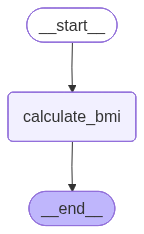

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())